In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from collections import Counter

# Windows Jupyter 路径
PROJECT_DIR = Path(r"\\wsl.localhost\Ubuntu\home\lly\projects\project")

HUMAN_TRACE_PATH = Path(
    r"D:\111\课程\master thesis\VLM behavior\Mid stage\week12\BLL\processed_traces\groupB_beer_aligned_burst_traces_v3_gap750ms.jsonl"
)

MODEL_TRACE_PATH = PROJECT_DIR / "processed_model_student_traces" / "model_student_simulation_beer_hmm_ready_traces_corrected.jsonl"

OUTPUT_DIR = PROJECT_DIR / "hmm_results_numpy_human_vs_model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Human path:", HUMAN_TRACE_PATH, HUMAN_TRACE_PATH.exists())
print("Model path:", MODEL_TRACE_PATH, MODEL_TRACE_PATH.exists())
print("Output dir:", OUTPUT_DIR)

Human path: D:\111\课程\master thesis\VLM behavior\Mid stage\week12\BLL\processed_traces\groupB_beer_aligned_burst_traces_v3_gap750ms.jsonl True
Model path: \\wsl.localhost\Ubuntu\home\lly\projects\project\processed_model_student_traces\model_student_simulation_beer_hmm_ready_traces_corrected.jsonl True
Output dir: \\wsl.localhost\Ubuntu\home\lly\projects\project\hmm_results_numpy_human_vs_model


In [4]:
def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records


human_records = read_jsonl(HUMAN_TRACE_PATH)
model_records = read_jsonl(MODEL_TRACE_PATH)

human_sequences = [r["v3_burst_trace"] for r in human_records]
model_sequences = [r["trace"] for r in model_records]

print("Human traces:", len(human_sequences))
print("Model traces:", len(model_sequences))

print("First human trace:", human_sequences[0][:30])
print("First model trace:", model_sequences[0][:30])

Human traces: 81
Model traces: 116
First human trace: ['increase_concentration', 'decrease_concentration', 'increase_concentration', 'increase_concentration', 'increase_concentration', 'increase_concentration', 'increase_concentration', 'decrease_concentration', 'increase_path_length', 'decrease_path_length', 'increase_path_length', 'decrease_path_length', 'increase_path_length', 'decrease_path_length', 'increase_path_length', 'increase_wavelength', 'increase_wavelength', 'decrease_wavelength', 'increase_wavelength', 'decrease_wavelength', 'increase_wavelength', 'increase_path_length', 'decrease_path_length', 'increase_path_length', 'increase_concentration', 'decrease_concentration', 'decrease_wavelength', 'increase_wavelength', 'decrease_wavelength', 'increase_concentration']
First model trace: ['increase_wavelength', 'increase_wavelength', 'increase_wavelength', 'increase_concentration', 'finish']


In [6]:
import numpy as np
import pandas as pd

BEER_ACTIONS = [
    "increase_wavelength",
    "decrease_wavelength",
    "increase_concentration",
    "decrease_concentration",
    "increase_path_length",
    "decrease_path_length",
    "finish",
]

action_to_id = {action: i for i, action in enumerate(BEER_ACTIONS)}
id_to_action = {i: action for action, i in action_to_id.items()}

print(action_to_id)

{'increase_wavelength': 0, 'decrease_wavelength': 1, 'increase_concentration': 2, 'decrease_concentration': 3, 'increase_path_length': 4, 'decrease_path_length': 5, 'finish': 6}


In [7]:
def encode_sequences(sequences, action_to_id):
    encoded = []
    lengths = []

    for seq in sequences:
        ids = [action_to_id[a] for a in seq]
        encoded.append(np.array(ids, dtype=np.int64))
        lengths.append(len(ids))

    return encoded, lengths


human_encoded, human_lengths = encode_sequences(human_sequences, action_to_id)
model_encoded, model_lengths = encode_sequences(model_sequences, action_to_id)

print("Human length summary:")
display(pd.Series(human_lengths).describe())

print("Model length summary:")
display(pd.Series(model_lengths).describe())

Human length summary:


count     81.000000
mean      67.506173
std       46.107788
min        7.000000
25%       37.000000
50%       58.000000
75%       84.000000
max      229.000000
dtype: float64

Model length summary:


count    116.000000
mean       9.344828
std        8.004459
min        2.000000
25%        5.000000
50%        7.000000
75%       10.000000
max       47.000000
dtype: float64

In [8]:
class NumpyCategoricalHMM:
    def __init__(
        self,
        n_states,
        n_observations,
        random_state=0,
        smoothing=1e-3,
        max_iter=200,
        tol=1e-4,
    ):
        self.n_states = n_states
        self.n_observations = n_observations
        self.random_state = random_state
        self.smoothing = smoothing
        self.max_iter = max_iter
        self.tol = tol

        self.pi = None
        self.A = None
        self.B = None
        self.history_ = []

    def _normalize(self, x, axis=None):
        x = np.asarray(x, dtype=float)
        s = x.sum(axis=axis, keepdims=True)
        s = np.where(s <= 0, 1.0, s)
        return x / s

    def _initialize_params(self):
        rng = np.random.default_rng(self.random_state)

        self.pi = rng.dirichlet(np.ones(self.n_states))
        self.A = rng.dirichlet(np.ones(self.n_states), size=self.n_states)
        self.B = rng.dirichlet(np.ones(self.n_observations), size=self.n_states)

    def _forward_scaled(self, obs):
        T = len(obs)
        K = self.n_states

        alpha = np.zeros((T, K))
        scale = np.zeros(T)

        alpha[0] = self.pi * self.B[:, obs[0]]
        scale[0] = alpha[0].sum()
        if scale[0] <= 0:
            scale[0] = 1e-300
        alpha[0] /= scale[0]

        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ self.A) * self.B[:, obs[t]]
            scale[t] = alpha[t].sum()
            if scale[t] <= 0:
                scale[t] = 1e-300
            alpha[t] /= scale[t]

        loglik = np.log(scale).sum()
        return alpha, scale, loglik

    def _backward_scaled(self, obs, scale):
        T = len(obs)
        K = self.n_states

        beta = np.zeros((T, K))
        beta[-1] = 1.0

        for t in range(T - 2, -1, -1):
            beta[t] = self.A @ (self.B[:, obs[t + 1]] * beta[t + 1])
            beta[t] /= scale[t + 1]

        return beta

    def _e_step_one(self, obs):
        T = len(obs)
        K = self.n_states
        M = self.n_observations

        alpha, scale, loglik = self._forward_scaled(obs)
        beta = self._backward_scaled(obs, scale)

        gamma = alpha * beta
        gamma = self._normalize(gamma, axis=1)

        xi_sum = np.zeros((K, K))

        for t in range(T - 1):
            xi = (
                alpha[t, :, None]
                * self.A
                * self.B[:, obs[t + 1]][None, :]
                * beta[t + 1][None, :]
            )

            denom = xi.sum()
            if denom > 0:
                xi /= denom
            xi_sum += xi

        emission_counts = np.zeros((K, M))
        for t, o in enumerate(obs):
            emission_counts[:, o] += gamma[t]

        return {
            "loglik": loglik,
            "gamma_start": gamma[0],
            "gamma_sum_except_last": gamma[:-1].sum(axis=0) if T > 1 else np.zeros(K),
            "xi_sum": xi_sum,
            "emission_counts": emission_counts,
        }

    def fit(self, sequences):
        self._initialize_params()

        prev_loglik = -np.inf
        self.history_ = []

        for iteration in range(1, self.max_iter + 1):
            pi_acc = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            B_num = np.zeros((self.n_states, self.n_observations))

            total_loglik = 0.0

            for obs in sequences:
                if len(obs) == 0:
                    continue

                stats = self._e_step_one(obs)

                total_loglik += stats["loglik"]
                pi_acc += stats["gamma_start"]
                A_num += stats["xi_sum"]
                A_den += stats["gamma_sum_except_last"]
                B_num += stats["emission_counts"]

            # M-step with smoothing
            self.pi = self._normalize(pi_acc + self.smoothing)

            self.A = A_num + self.smoothing
            self.A = self._normalize(self.A, axis=1)

            self.B = B_num + self.smoothing
            self.B = self._normalize(self.B, axis=1)

            improvement = total_loglik - prev_loglik

            self.history_.append({
                "iteration": iteration,
                "loglik": total_loglik,
                "improvement": improvement,
            })

            if iteration > 1 and abs(improvement) < self.tol:
                break

            prev_loglik = total_loglik

        return self

    def score(self, obs):
        _, _, loglik = self._forward_scaled(obs)
        return loglik

    def predict(self, obs):
        T = len(obs)
        K = self.n_states

        log_pi = np.log(self.pi + 1e-300)
        log_A = np.log(self.A + 1e-300)
        log_B = np.log(self.B + 1e-300)

        delta = np.zeros((T, K))
        psi = np.zeros((T, K), dtype=int)

        delta[0] = log_pi + log_B[:, obs[0]]

        for t in range(1, T):
            scores = delta[t - 1][:, None] + log_A
            psi[t] = np.argmax(scores, axis=0)
            delta[t] = np.max(scores, axis=0) + log_B[:, obs[t]]

        states = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])

        for t in range(T - 2, -1, -1):
            states[t] = psi[t + 1, states[t + 1]]

        return states

In [10]:
import time
import pandas as pd
import numpy as np

def fit_multiple_hmms(
    sequences,
    n_states=4,
    n_observations=7,
    seeds=range(10),
    max_iter=150,
    tol=1e-4,
    smoothing=1e-3,
    verbose=True,
):
    """
    Fit multiple HMMs with different random seeds and return the best one
    according to total training log-likelihood.

    Parameters
    ----------
    sequences : list[list[int]]
        Encoded action sequences.
    n_states : int
        Number of hidden states.
    n_observations : int
        Number of discrete action types.
    seeds : iterable
        Random seeds to try.
    max_iter : int
        Maximum EM iterations for each HMM.
    tol : float
        Early stopping threshold.
    smoothing : float
        Additive smoothing for transition/emission probabilities.
    verbose : bool
        Whether to print progress.

    Returns
    -------
    best_model : NumpyCategoricalHMM
        Best fitted HMM.
    seed_df : pd.DataFrame
        Summary of all fitted seeds.
    """
    seeds = list(seeds)

    if len(sequences) == 0:
        raise ValueError("sequences is empty.")

    if verbose:
        lengths = [len(seq) for seq in sequences]
        print("=" * 80)
        print("Fitting multiple HMMs")
        print(f"Number of sequences: {len(sequences)}")
        print(f"Sequence length: min={min(lengths)}, mean={np.mean(lengths):.2f}, max={max(lengths)}")
        print(f"n_states: {n_states}")
        print(f"n_observations: {n_observations}")
        print(f"seeds: {seeds}")
        print(f"max_iter: {max_iter}")
        print("=" * 80)

    rows = []
    models_by_seed = {}

    total_start = time.time()

    for i, seed in enumerate(seeds, start=1):
        seed_start = time.time()

        if verbose:
            print(f"\n[{i}/{len(seeds)}] Training seed={seed} ...")

        model = NumpyCategoricalHMM(
            n_states=n_states,
            n_observations=n_observations,
            random_state=seed,
            smoothing=smoothing,
            max_iter=max_iter,
            tol=tol,
        )

        model.fit(sequences)

        train_loglik = sum(model.score(seq) for seq in sequences)
        n_iter = len(model.history_)

        if n_iter > 0 and "improvement" in model.history_[-1]:
            final_improvement = model.history_[-1]["improvement"]
        else:
            final_improvement = np.nan

        elapsed = time.time() - seed_start

        rows.append({
            "seed": seed,
            "n_states": n_states,
            "train_loglik": train_loglik,
            "mean_train_loglik_per_seq": train_loglik / len(sequences),
            "n_iter": n_iter,
            "final_improvement": final_improvement,
            "elapsed_sec": elapsed,
        })

        models_by_seed[seed] = model

        if verbose:
            print(f"  train_loglik: {train_loglik:.3f}")
            print(f"  mean per sequence: {train_loglik / len(sequences):.3f}")
            print(f"  n_iter: {n_iter}")
            print(f"  final improvement: {final_improvement}")
            print(f"  elapsed: {elapsed:.2f} sec")

    seed_df = pd.DataFrame(rows).sort_values("train_loglik", ascending=False).reset_index(drop=True)

    best_seed = int(seed_df.iloc[0]["seed"])
    best_model = models_by_seed[best_seed]

    total_elapsed = time.time() - total_start

    if verbose:
        print("\n" + "=" * 80)
        print("Finished HMM seed search")
        print(f"Best seed: {best_seed}")
        print(f"Best train_loglik: {seed_df.iloc[0]['train_loglik']:.3f}")
        print(f"Total elapsed: {total_elapsed:.2f} sec")
        print("=" * 80)

    return best_model, seed_df

In [11]:
N_STATES = 4

human_hmm, hmm_seed_df = fit_multiple_hmms(
    sequences=human_encoded,
    n_states=N_STATES,
    n_observations=len(BEER_ACTIONS),
    seeds=range(10),
    max_iter=150,
    tol=1e-4,
    smoothing=1e-3,
    verbose=True,
)

display(hmm_seed_df)

Fitting multiple HMMs
Number of sequences: 81
Sequence length: min=7, mean=67.51, max=229
n_states: 4
n_observations: 7
seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
max_iter: 150

[1/10] Training seed=0 ...
  train_loglik: -6878.175
  mean per sequence: -84.916
  n_iter: 150
  final improvement: 0.00016327017146977596
  elapsed: 55.81 sec

[2/10] Training seed=1 ...
  train_loglik: -6878.175
  mean per sequence: -84.916
  n_iter: 150
  final improvement: 0.00016838166266097687
  elapsed: 42.04 sec

[3/10] Training seed=2 ...
  train_loglik: -7758.079
  mean per sequence: -95.779
  n_iter: 150
  final improvement: 0.003551086870174913
  elapsed: 38.58 sec

[4/10] Training seed=3 ...
  train_loglik: -7564.538
  mean per sequence: -93.389
  n_iter: 101
  final improvement: 9.374072396894917e-05
  elapsed: 25.72 sec

[5/10] Training seed=4 ...
  train_loglik: -6766.436
  mean per sequence: -83.536
  n_iter: 97
  final improvement: 9.864394087344408e-05
  elapsed: 33.54 sec

[6/10] Training seed=5

,seed,n_states,train_loglik,mean_train_loglik_per_seq,n_iter,final_improvement,elapsed_sec
0,6,4,-6766.434242,-83.536225,127,0.000096,49.034354
1,7,4,-6766.435283,-83.536238,122,0.000097,32.608929
2,9,4,-6766.435317,-83.536238,87,0.000096,22.501365
3,4,4,-6766.435708,-83.536243,97,0.000099,33.540909
4,0,4,-6878.174726,-84.915737,150,0.000163,55.807606
5,1,4,-6878.175091,-84.915742,150,0.000168,42.043457
6,8,4,-7030.064218,-86.790916,150,0.007615,37.558918
7,5,4,-7554.720862,-93.268159,110,0.000095,39.564992
8,3,4,-7564.537877,-93.389357,101,0.000094,25.715477
9,2,4,-7758.078842,-95.778751,150,0.003551,38.577778


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def score_sequences_with_hmm(sequences, raw_sequences, hmm_model, group_name="unknown"):
    """
    Score action sequences under a fitted HMM.

    Parameters
    ----------
    sequences : list[np.ndarray]
        Encoded action sequences.
    raw_sequences : list[list[str]]
        Original string action sequences.
    hmm_model : fitted NumpyCategoricalHMM
        Human-trained HMM.
    group_name : str
        Label, e.g. "human" or "model".

    Returns
    -------
    pd.DataFrame
    """
    rows = []

    for i, seq in enumerate(sequences):
        seq = np.asarray(seq, dtype=np.int64)
        length = len(seq)

        if length == 0:
            total_loglik = np.nan
            mean_loglik = np.nan
        else:
            total_loglik = hmm_model.score(seq)
            mean_loglik = total_loglik / length

        rows.append({
            "trace_index": i,
            "group": group_name,
            "length": length,
            "total_loglik": total_loglik,
            "mean_loglik_per_step": mean_loglik,
            "action_sequence": raw_sequences[i],
            "action_sequence_str": " -> ".join(raw_sequences[i]),
        })

    return pd.DataFrame(rows)


human_score_df = score_sequences_with_hmm(
    sequences=human_encoded,
    raw_sequences=human_sequences,
    hmm_model=human_hmm,
    group_name="human",
)

model_score_df = score_sequences_with_hmm(
    sequences=model_encoded,
    raw_sequences=model_sequences,
    hmm_model=human_hmm,
    group_name="model",
)

all_score_df = pd.concat([human_score_df, model_score_df], ignore_index=True)

print("Human scores:")
display(human_score_df.head())

print("Model scores:")
display(model_score_df.head())

Human scores:


,trace_index,group,length,total_loglik,mean_loglik_per_step,action_sequence,action_sequence_str
0,0,human,79,-116.707585,-1.477311,"[increase_concentration, decrease_concentratio...",increase_concentration -> decrease_concentrati...
1,1,human,21,-24.963376,-1.188732,"[increase_concentration, decrease_concentratio...",increase_concentration -> decrease_concentrati...
2,2,human,55,-73.611827,-1.338397,"[increase_wavelength, decrease_wavelength, inc...",increase_wavelength -> decrease_wavelength -> ...
3,3,human,33,-37.300690,-1.130324,"[decrease_wavelength, increase_wavelength, dec...",decrease_wavelength -> increase_wavelength -> ...
4,4,human,43,-57.867015,-1.345745,"[increase_concentration, increase_wavelength, ...",increase_concentration -> increase_wavelength ...


Model scores:


,trace_index,group,length,total_loglik,mean_loglik_per_step,action_sequence,action_sequence_str
0,0,model,5,-10.981209,-2.196242,"[increase_wavelength, increase_wavelength, inc...",increase_wavelength -> increase_wavelength -> ...
1,1,model,5,-10.842432,-2.168486,"[increase_concentration, increase_path_length,...",increase_concentration -> increase_path_length...
2,2,model,4,-12.040841,-3.010210,"[increase_concentration, increase_path_length,...",increase_concentration -> increase_path_length...
3,3,model,6,-13.534186,-2.255698,"[increase_wavelength, increase_path_length, in...",increase_wavelength -> increase_path_length ->...
4,4,model,4,-8.649258,-2.162314,"[increase_wavelength, decrease_wavelength, inc...",increase_wavelength -> decrease_wavelength -> ...


In [13]:
human_mean = human_score_df["mean_loglik_per_step"].mean()
human_std = human_score_df["mean_loglik_per_step"].std(ddof=1)

print("Human reference mean:", human_mean)
print("Human reference std:", human_std)

def add_human_reference_metrics(df, human_scores):
    """
    Add z-score and percentile relative to human training traces.
    Higher score means more human-like under the human-trained HMM.
    """
    df = df.copy()

    ref = np.asarray(human_scores, dtype=float)
    ref = ref[~np.isnan(ref)]

    mu = ref.mean()
    sigma = ref.std(ddof=1)

    df["human_likeness_z"] = (df["mean_loglik_per_step"] - mu) / sigma

    percentiles = []
    for x in df["mean_loglik_per_step"]:
        if pd.isna(x):
            percentiles.append(np.nan)
        else:
            percentiles.append((ref <= x).mean())

    df["human_likeness_percentile"] = percentiles

    return df


human_score_df = add_human_reference_metrics(
    human_score_df,
    human_score_df["mean_loglik_per_step"],
)

model_score_df = add_human_reference_metrics(
    model_score_df,
    human_score_df["mean_loglik_per_step"],
)

all_score_df = pd.concat([human_score_df, model_score_df], ignore_index=True)

display(model_score_df.head())

Human reference mean: -1.3284194110103882
Human reference std: 0.31598879940683705


,trace_index,group,length,total_loglik,mean_loglik_per_step,action_sequence,action_sequence_str,human_likeness_z,human_likeness_percentile
0,0,model,5,-10.981209,-2.196242,"[increase_wavelength, increase_wavelength, inc...",increase_wavelength -> increase_wavelength -> ...,-2.746371,0.024691
1,1,model,5,-10.842432,-2.168486,"[increase_concentration, increase_path_length,...",increase_concentration -> increase_path_length...,-2.658534,0.024691
2,2,model,4,-12.040841,-3.010210,"[increase_concentration, increase_path_length,...",increase_concentration -> increase_path_length...,-5.322312,0.000000
3,3,model,6,-13.534186,-2.255698,"[increase_wavelength, increase_path_length, in...",increase_wavelength -> increase_path_length ->...,-2.934529,0.012346
4,4,model,4,-8.649258,-2.162314,"[increase_wavelength, decrease_wavelength, inc...",increase_wavelength -> decrease_wavelength -> ...,-2.639002,0.024691


In [14]:
summary_df = (
    all_score_df
    .groupby("group")
    .agg(
        n_traces=("trace_index", "count"),
        mean_length=("length", "mean"),
        median_length=("length", "median"),
        mean_loglik=("mean_loglik_per_step", "mean"),
        median_loglik=("mean_loglik_per_step", "median"),
        std_loglik=("mean_loglik_per_step", "std"),
        mean_human_likeness_z=("human_likeness_z", "mean"),
        median_human_likeness_z=("human_likeness_z", "median"),
        mean_human_likeness_percentile=("human_likeness_percentile", "mean"),
        median_human_likeness_percentile=("human_likeness_percentile", "median"),
    )
    .reset_index()
)

display(summary_df)

,group,n_traces,mean_length,median_length,mean_loglik,median_loglik,std_loglik,mean_human_likeness_z,median_human_likeness_z,mean_human_likeness_percentile,median_human_likeness_percentile
0,human,81,67.506173,58.0,-1.328419,-1.269759,0.315989,5.619647e-16,0.185642,0.506173,0.506173
1,model,116,9.344828,7.0,-2.180920,-2.165400,0.372245,-2.697882e+00,-2.648768,0.047680,0.024691


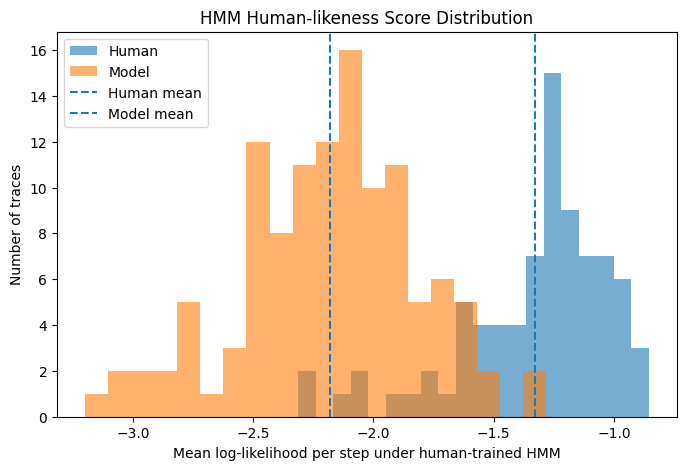

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    human_score_df["mean_loglik_per_step"].dropna(),
    bins=20,
    alpha=0.6,
    label="Human",
)

plt.hist(
    model_score_df["mean_loglik_per_step"].dropna(),
    bins=20,
    alpha=0.6,
    label="Model",
)

plt.axvline(
    human_score_df["mean_loglik_per_step"].mean(),
    linestyle="--",
    label="Human mean",
)

plt.axvline(
    model_score_df["mean_loglik_per_step"].mean(),
    linestyle="--",
    label="Model mean",
)

plt.title("HMM Human-likeness Score Distribution")
plt.xlabel("Mean log-likelihood per step under human-trained HMM")
plt.ylabel("Number of traces")
plt.legend()
plt.show()

C:\Users\14257\AppData\Local\Temp\ipykernel_83184\3977699794.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Human", "Model"])


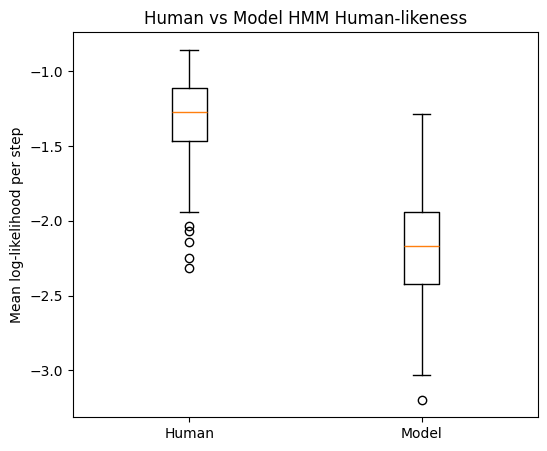

In [16]:
plt.figure(figsize=(6, 5))

data_to_plot = [
    human_score_df["mean_loglik_per_step"].dropna(),
    model_score_df["mean_loglik_per_step"].dropna(),
]

plt.boxplot(data_to_plot, labels=["Human", "Model"])

plt.title("Human vs Model HMM Human-likeness")
plt.ylabel("Mean log-likelihood per step")
plt.show()

In [17]:
top_humanlike_models = (
    model_score_df
    .sort_values("mean_loglik_per_step", ascending=False)
    .head(10)
)

display(
    top_humanlike_models[
        [
            "trace_index",
            "length",
            "mean_loglik_per_step",
            "human_likeness_z",
            "human_likeness_percentile",
            "action_sequence_str",
        ]
    ]
)

,trace_index,length,mean_loglik_per_step,human_likeness_z,human_likeness_percentile,action_sequence_str
54,54,25,-1.282117,0.146530,0.469136,increase_wavelength -> increase_wavelength -> ...
14,14,25,-1.291558,0.116655,0.419753,increase_wavelength -> decrease_concentration ...
75,75,20,-1.504347,-0.556752,0.234568,increase_wavelength -> increase_concentration ...
41,41,9,-1.513981,-0.587242,0.222222,increase_wavelength -> increase_wavelength -> ...
34,34,6,-1.588004,-0.821500,0.185185,increase_concentration -> increase_concentrati...
44,44,12,-1.645034,-1.001982,0.123457,increase_wavelength -> increase_wavelength -> ...
39,39,8,-1.646050,-1.005195,0.123457,increase_wavelength -> increase_wavelength -> ...
62,62,9,-1.655394,-1.034767,0.123457,increase_wavelength -> increase_wavelength -> ...
48,48,15,-1.655638,-1.035538,0.123457,increase_concentration -> increase_concentrati...
66,66,10,-1.715432,-1.224765,0.111111,increase_wavelength -> increase_wavelength -> ...


In [18]:
top_humanlike_models = (
    model_score_df
    .sort_values("mean_loglik_per_step", ascending=False)
    .head(10)
)

display(
    top_humanlike_models[
        [
            "trace_index",
            "length",
            "mean_loglik_per_step",
            "human_likeness_z",
            "human_likeness_percentile",
            "action_sequence_str",
        ]
    ]
)

,trace_index,length,mean_loglik_per_step,human_likeness_z,human_likeness_percentile,action_sequence_str
54,54,25,-1.282117,0.146530,0.469136,increase_wavelength -> increase_wavelength -> ...
14,14,25,-1.291558,0.116655,0.419753,increase_wavelength -> decrease_concentration ...
75,75,20,-1.504347,-0.556752,0.234568,increase_wavelength -> increase_concentration ...
41,41,9,-1.513981,-0.587242,0.222222,increase_wavelength -> increase_wavelength -> ...
34,34,6,-1.588004,-0.821500,0.185185,increase_concentration -> increase_concentrati...
44,44,12,-1.645034,-1.001982,0.123457,increase_wavelength -> increase_wavelength -> ...
39,39,8,-1.646050,-1.005195,0.123457,increase_wavelength -> increase_wavelength -> ...
62,62,9,-1.655394,-1.034767,0.123457,increase_wavelength -> increase_wavelength -> ...
48,48,15,-1.655638,-1.035538,0.123457,increase_concentration -> increase_concentrati...
66,66,10,-1.715432,-1.224765,0.111111,increase_wavelength -> increase_wavelength -> ...


In [19]:
least_humanlike_models = (
    model_score_df
    .sort_values("mean_loglik_per_step", ascending=True)
    .head(10)
)

display(
    least_humanlike_models[
        [
            "trace_index",
            "length",
            "mean_loglik_per_step",
            "human_likeness_z",
            "human_likeness_percentile",
            "action_sequence_str",
        ]
    ]
)

,trace_index,length,mean_loglik_per_step,human_likeness_z,human_likeness_percentile,action_sequence_str
30,30,6,-3.197846,-5.916117,0.0,increase_wavelength -> decrease_concentration ...
36,36,4,-3.031527,-5.389772,0.0,increase_wavelength -> decrease_concentration ...
2,2,4,-3.010210,-5.322312,0.0,increase_concentration -> increase_path_length...
87,87,7,-3.001419,-5.294491,0.0,increase_wavelength -> increase_concentration ...
114,114,7,-3.001419,-5.294491,0.0,increase_wavelength -> increase_concentration ...
89,89,4,-2.898674,-4.969338,0.0,increase_wavelength -> decrease_concentration ...
105,105,10,-2.870301,-4.879546,0.0,increase_wavelength -> increase_concentration ...
63,63,3,-2.788265,-4.619929,0.0,decrease_wavelength -> decrease_wavelength -> ...
7,7,5,-2.748203,-4.493146,0.0,increase_wavelength -> increase_concentration ...
57,57,14,-2.738956,-4.463883,0.0,increase_wavelength -> decrease_path_length ->...


In [20]:
cols = [
    "trace_index",
    "model",
    "modality",
    "length",
    "mean_loglik_per_step",
    "human_likeness_z",
    "human_likeness_percentile",
    "action_sequence_str",
]

available_cols = [c for c in cols if c in model_score_df.columns]

most_humanlike = (
    model_score_df
    .sort_values("mean_loglik_per_step", ascending=False)
    .head(1)
)

least_humanlike = (
    model_score_df
    .sort_values("mean_loglik_per_step", ascending=True)
    .head(1)
)

print("Most human-like model trace:")
display(most_humanlike[available_cols].T)

print("Least human-like model trace:")
display(least_humanlike[available_cols].T)

Most human-like model trace:


,54
trace_index,54
length,25
mean_loglik_per_step,-1.282117
human_likeness_z,0.14653
human_likeness_percentile,0.469136
action_sequence_str,increase_wavelength -> increase_wavelength -> ...


Least human-like model trace:


,30
trace_index,30
length,6
mean_loglik_per_step,-3.197846
human_likeness_z,-5.916117
human_likeness_percentile,0.0
action_sequence_str,increase_wavelength -> decrease_concentration ...


In [21]:
# 先确认你的原始 model dataframe 叫什么
for name in ["model_df", "model_data_df", "model_trace_df", "all_model_df", "df"]:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, "columns"):
            print("\nFOUND:", name)
            print("shape:", obj.shape)
            print("columns:", obj.columns.tolist())

In [25]:
import pandas as pd

print("Existing DataFrames:")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print("\nNAME:", name)
        print("SHAPE:", obj.shape)
        print("COLUMNS:", obj.columns.tolist())

Existing DataFrames:

NAME: hmm_seed_df
SHAPE: (10, 7)
COLUMNS: ['seed', 'n_states', 'train_loglik', 'mean_train_loglik_per_seq', 'n_iter', 'final_improvement', 'elapsed_sec']

NAME: human_score_df
SHAPE: (81, 9)
COLUMNS: ['trace_index', 'group', 'length', 'total_loglik', 'mean_loglik_per_step', 'action_sequence', 'action_sequence_str', 'human_likeness_z', 'human_likeness_percentile']

NAME: model_score_df
SHAPE: (116, 9)
COLUMNS: ['trace_index', 'group', 'length', 'total_loglik', 'mean_loglik_per_step', 'action_sequence', 'action_sequence_str', 'human_likeness_z', 'human_likeness_percentile']

NAME: all_score_df
SHAPE: (197, 9)
COLUMNS: ['trace_index', 'group', 'length', 'total_loglik', 'mean_loglik_per_step', 'action_sequence', 'action_sequence_str', 'human_likeness_z', 'human_likeness_percentile']

NAME: summary_df
SHAPE: (2, 11)
COLUMNS: ['group', 'n_traces', 'mean_length', 'median_length', 'mean_loglik', 'median_loglik', 'std_loglik', 'mean_human_likeness_z', 'median_human_likenes

In [26]:
import pandas as pd

candidate_dfs = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)
        useful_cols = cols.intersection({
            "model",
            "modality",
            "project",
            "run_name",
            "condition",
            "setup",
            "formula",
            "trajectory",
            "action_sequence",
            "actions",
        })

        if len(useful_cols) > 0:
            candidate_dfs.append(name)
            print("\nCANDIDATE DF:", name)
            print("SHAPE:", obj.shape)
            print("MATCHED COLUMNS:", sorted(useful_cols))
            print("ALL COLUMNS:", obj.columns.tolist())

print("\nCandidate DataFrames:", candidate_dfs)


CANDIDATE DF: human_score_df
SHAPE: (81, 9)
MATCHED COLUMNS: ['action_sequence']
ALL COLUMNS: ['trace_index', 'group', 'length', 'total_loglik', 'mean_loglik_per_step', 'action_sequence', 'action_sequence_str', 'human_likeness_z', 'human_likeness_percentile']

CANDIDATE DF: model_score_df
SHAPE: (116, 9)
MATCHED COLUMNS: ['action_sequence']
ALL COLUMNS: ['trace_index', 'group', 'length', 'total_loglik', 'mean_loglik_per_step', 'action_sequence', 'action_sequence_str', 'human_likeness_z', 'human_likeness_percentile']

CANDIDATE DF: all_score_df
SHAPE: (197, 9)
MATCHED COLUMNS: ['action_sequence']
ALL COLUMNS: ['trace_index', 'group', 'length', 'total_loglik', 'mean_loglik_per_step', 'action_sequence', 'action_sequence_str', 'human_likeness_z', 'human_likeness_percentile']

CANDIDATE DF: top_humanlike_models
SHAPE: (10, 9)
MATCHED COLUMNS: ['action_sequence']
ALL COLUMNS: ['trace_index', 'group', 'length', 'total_loglik', 'mean_loglik_per_step', 'action_sequence', 'action_sequence_str',

In [27]:
import json
from pathlib import Path

trace_path = Path(r"D:\111\课程\master thesis\VLM behavior\Mid stage\week12\BLL\processed_traces\groupB_beer_aligned_burst_traces_v3_gap750ms.jsonl")

records = []
with open(trace_path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

print("n traces:", len(records))

for i, r in enumerate(records[:10]):
    print("=" * 80)
    print("trace index:", i)
    print("file:", r["file"])
    print("session_code:", r["session_code"])
    print("subgroup:", r["subgroup"])
    print("n actions:", r["n_burst_actions_v3"])
    print("trace:")
    print(" -> ".join(r["v3_burst_trace"]))

n traces: 81
trace index: 0
file: ex_bckp1-B-DC_sim1.pkl
session_code: ex_bckp1-B-DC
subgroup: DC
n actions: 79
trace:
increase_concentration -> decrease_concentration -> increase_concentration -> increase_concentration -> increase_concentration -> increase_concentration -> increase_concentration -> decrease_concentration -> increase_path_length -> decrease_path_length -> increase_path_length -> decrease_path_length -> increase_path_length -> decrease_path_length -> increase_path_length -> increase_wavelength -> increase_wavelength -> decrease_wavelength -> increase_wavelength -> decrease_wavelength -> increase_wavelength -> increase_path_length -> decrease_path_length -> increase_path_length -> increase_concentration -> decrease_concentration -> decrease_wavelength -> increase_wavelength -> decrease_wavelength -> increase_concentration -> decrease_concentration -> decrease_wavelength -> decrease_wavelength -> increase_concentration -> decrease_concentration -> increase_concentration -